# BÁO CÁO: THUẬT TOÁN EXPECTATION-MAXIMIZATION (EM)

## 1. Giới thiệu
Thuật toán EM thường được dùng để ước lượng tham số của các mô hình xác suất, phổ biến nhất là **Gaussian Mixture Models (GMM)**. Nó giải quyết bài toán khi dữ liệu có các biến ẩn không quan sát được.

## 2. Quy trình hoạt động
Thuật toán lặp qua hai bước chính:
1. **E-Step (Expectation):** Tính toán xác suất (trọng số) để mỗi điểm dữ liệu thuộc về từng phân phối thành phần.
2. **M-Step (Maximization):** Cập nhật các tham số (Trung bình $\mu$, Phương sai $\sigma^2$, và Trọng số $\pi$) để tối đa hóa hàm hợp lý (Likelihood).

## 3. So sánh với K-means
- K-means thực hiện "phân cụm cứng" (một điểm chỉ thuộc một cụm).
- EM/GMM thực hiện "phân cụm mềm" (một điểm có xác suất thuộc về nhiều cụm khác nhau), giúp xử lý tốt các cụm có hình dạng elip hoặc chồng lấn nhau.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

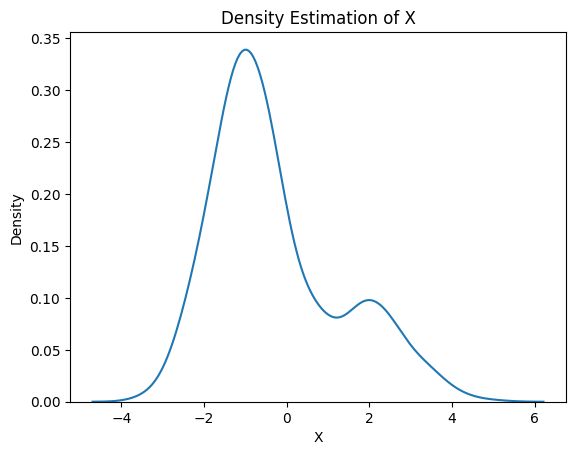

In [2]:
mu1, sigma1 = 2, 1
mu2, sigma2 = -1, 0.8

X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

sns.kdeplot(X)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()

In [3]:
mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1) / len(X), len(X2) / len(X)

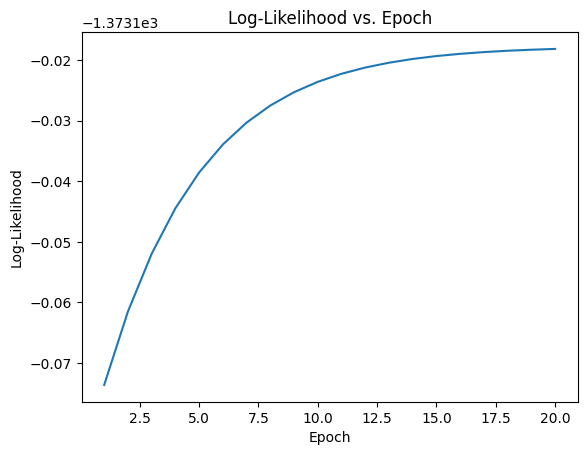

In [4]:
num_epochs = 20
log_likelihoods = []

for epoch in range(num_epochs):
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
    total = gamma1 + gamma2
    gamma1 /= total
    gamma2 /= total

    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)
    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat)**2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat)**2) / np.sum(gamma2))
    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)

    log_likelihood = np.sum(np.log(pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
                                   + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)))
    log_likelihoods.append(log_likelihood)


plt.plot(range(1, num_epochs + 1), log_likelihoods)
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs. Epoch')
plt.show()

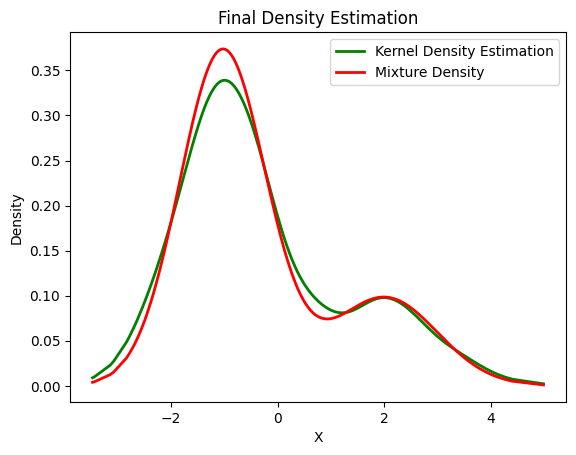

In [5]:
X_sorted = np.sort(X)
density_estimation = (pi1_hat * norm.pdf(X_sorted, mu1_hat, sigma1_hat) +
                      pi2_hat * norm.pdf(X_sorted, mu2_hat, sigma2_hat))

plt.plot(X_sorted, gaussian_kde(X_sorted)(
    X_sorted), color='green', linewidth=2)
plt.plot(X_sorted, density_estimation, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Final Density Estimation')
plt.legend(['Kernel Density Estimation', 'Mixture Density'])
plt.show()